# 2. Cruzamento dos Dados (Enunciados + Microdados)

* **Input**: Local do CSV de Questões Extraídas + Local do CSV de Microdados

* **Output**: CSV com as colunas -> *numero_questao*, *enunciado*, *alternativas*, *nu_param_B* e *gabarito*

In [1]:
# Dependências para Cruzamento dos Dados
import pandas as pd
import matplotlib.pyplot as plt

## 2.1. Extraindo e Cruzando Microdados

In [2]:
codigos_prova = {
    "2009": 49,
    "2010": 89,
    "2011": 121,
    "2012": 141,
    "2013": 171,
    "2014": 199,
    "2015": 275,
    "2016": 291,
    "2017_LEDOR": 407,
    "2018_LEDOR": 463,
    "2019_LEDOR": 519,
    "2020_LEDOR": 604,
    "2021_LEDOR": 916,
    "2022_LEDOR": 1092,
    "2023_LEDOR": 1228,
}

In [3]:
# Definição de Variáveis de Input e Output
start_year = 2009
end_year = 2023

output_path = "../data/final/enem_data.csv"

In [13]:
# Lista para armazenar os DataFrames de cada ano
merged_dfs = []

# Iterando sobre cada ano extraído
for year in range(start_year, end_year + 1):

    # Extrair da Prova LEDOR a partir de 2017 (mais descritiva)
    flag_ledor: bool = year >= 2017
    questions_year = str(year)
    if flag_ledor:
        questions_year += "_LEDOR"

    # Ler o CSV extraído do PDF referente (resultado de 1. Extração dos Enunciados.ipynb + Revisão Manual)
    df_questions = pd.read_csv(f"../data/processed_reviewed/enem_{questions_year}.csv", encoding="utf-8", quotechar='"')

    # Ler os CSVs de microdados do ano referente
    df_microdados = pd.read_csv(f"../data/raw/microdados/microdados_{year}.csv", delimiter=";", encoding="latin1")
    df_respostas = pd.read_csv(f"../data/raw/microdados/amostra_microdados_respostas_{year}.csv", delimiter=";", encoding="latin1")

    # Preparação de df_respostas para merge com prova
    quest_cols = [int(col.split("_")[1]) for col in df_respostas.columns if col.startswith('questao_')]

    df_respostas = pd.DataFrame({
        'questao': quest_cols,
        'respostas': pd.Series([df_respostas["questao_" + str(col)].tolist() for col in quest_cols])
    })

    if year == 2009:
        df_respostas["questao"] = df_respostas["questao"] 
    elif year <= 2016:
        df_respostas["questao"] += 45
    elif year <= 2023:
        df_respostas["questao"] += 90

    # Filtrando os microdados para SG_AREA, TX_COR e CO_PROVA
    # ATENÇÃO: O Código da Prova para a Aplicação Regular muda a cada ano
    cor_prova = "LARANJA" if flag_ledor else "AZUL"
    df_microdados_filtrado = df_microdados[
        (df_microdados["SG_AREA"] == "CN")  # Ciência das Naturezas
        & (
            (df_microdados["TX_COR"].str.upper() == cor_prova) 
        )  # Apenas caderno azul e laranja em caso de LEDOR
        & (df_microdados["CO_PROVA"] == codigos_prova[questions_year])  # Aplicação Regular ou LEDOR
    ]


    # Selecionar apenas as colunas de interesse dos microdados
    df_microdados_selected = df_microdados_filtrado[
        ["CO_POSICAO", "NU_PARAM_B", "TX_GABARITO"]
    ].copy()

    # Fix no ano de 2016 e 2017 (erro microdados)
    if year == 2017:
        df_microdados_selected["CO_POSICAO"] += 90
    if year == 2016:
        df_microdados_selected["CO_POSICAO"] -= 45

    # Certificar que os tipos das chaves de junção são compatíveis
    df_respostas["questao"] = df_respostas["questao"].astype(str)
    df_questions["numero_questao"] = df_questions["numero_questao"].astype(str)
    df_microdados_selected["CO_POSICAO"] = df_microdados_selected["CO_POSICAO"].astype(str)

    # Fazer o cruzamento usando o número da questão (numero_questao e CO_POSICAO)
    df_merged = pd.merge(
        df_questions,
        df_microdados_selected,
        left_on="numero_questao",
        right_on="CO_POSICAO",
        how="left",
    )
    
    # Fazer o cruzamento usando o número da questão (numero_questao e questao)
    df_merged = pd.merge(
        df_merged,
        df_respostas,
        left_on="numero_questao",
        right_on="questao",
        how="left",
    )

    # Calculando percentual de acertos da amostra
    df_merged['pc_amostra_acertos'] = df_merged.apply(
        lambda row: row['respostas'].count(row['TX_GABARITO']) / len(row['respostas']),
        axis=1
    )

    # Remover a coluna CO_POSICAO (redundante)
    df_merged.drop(columns=["CO_POSICAO", "respostas"], inplace=True)

    # Renomeando colunas
    df_merged.rename(columns={
        "NU_PARAM_B": "nu_param_B",
        "TX_GABARITO": "gabarito"
    }, inplace=True)

    # Adicionando coluna do ano
    df_merged["ano"] = year

    merged_dfs.append(df_merged)

# Concatenar todos os DataFrames em um único
df_final = pd.concat(merged_dfs, ignore_index=True)

# Salvando DF resultante
df_final.to_csv(output_path, index=False, encoding="utf-8")

In [14]:
df = pd.read_csv(output_path)
df.head()

,numero_questao,enunciado,alternativas,nu_param_B,gabarito,questao,pc_amostra_acertos,ano
0,1,A atmosfera terrestre é composta pelos gases n...,A: reduzir o calor irradiado pela Terra median...,-1.70677,C,1,0.93,2009
1,2,Analise a figura. Supondo que seja necessário ...,A: Concentração média de álcool no sangue ao l...,0.62043,D,2,0.40,2009
2,3,Estima-se que haja atualmente no mundo 40 milh...,"A: induzir a imunidade, para proteger o organi...",2.07704,A,3,0.40,2009
3,4,"Em um experimento, preparou-se um conjunto de ...",A: os genótipos e os fenótipos idênticos.; B: ...,0.11500,B,4,0.61,2009
4,5,"Na linha de uma tradição antiga, o astrônomo g...",A: Ptolomeu apresentou as ideias mais valiosas...,0.21694,E,5,0.60,2009


## 2.2. Removendo Questões sem Parâmetro B

In [15]:
num_nulos = df_final["nu_param_B"].isna().sum()
print(f"Questões sem parâmetro B (dificuldade): {num_nulos}")

Questões sem parâmetro B (dificuldade): 16


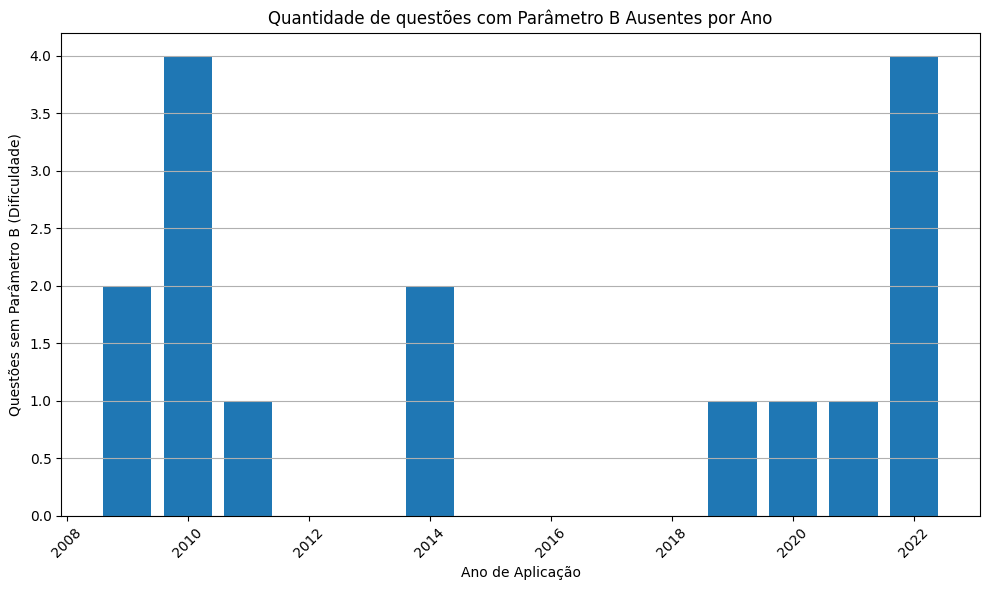

In [16]:
# Filtrar valores ausentes e agrupar por ano
missing_df = df_final[df_final["nu_param_B"].isna()].groupby("ano").size().reset_index(name="missing_nu_param_B")

# Plotar o gráfico
plt.figure(figsize=(10, 6))
plt.bar(missing_df["ano"], missing_df["missing_nu_param_B"])
plt.title("Quantidade de questões com Parâmetro B Ausentes por Ano")
plt.xlabel("Ano de Aplicação")
plt.ylabel("Questões sem Parâmetro B (Dificuldade)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')

plt.show()

In [17]:
# Remover linhas sem valor em nu_param_B
df_final = df_final.dropna(subset=["nu_param_B"])

# Salvando DF resultante
df_final.to_csv(output_path, index=False, encoding="utf-8")

print("Questões sem parâmetro de dificuldade removidas")

Questões sem parâmetro de dificuldade removidas
